In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import networkx as nx
from networkx.algorithms.community import louvain_communities


In [4]:
# Load LOP edges 
lop_edges = pd.read_csv("../data/preprocessed/lop_edges.csv")

# Build undirected weighted graph
G_undirected = nx.Graph()

for _, row in lop_edges.iterrows():
    u = int(row["pre"])
    v = int(row["post"])
    w = row["weight"]
    
    if G_undirected.has_edge(u, v):
        G_undirected[u][v]["weight"] += w
    else:
        G_undirected.add_edge(u, v, weight=w)

print("Nodes:", G_undirected.number_of_nodes())
print("Edges:", G_undirected.number_of_edges())
print("Total weight:", sum(d["weight"] for _, _, d in G_undirected.edges(data=True)))


Nodes: 1913
Edges: 18090
Total weight: 331113


In [14]:
# Run Louvain on undirected LOP graph


communities = louvain_communities(
    G_undirected,
    weight="weight",
    seed=42
)



In [17]:
# Nodes in the undirected graph (order matters)
node_list = list(G_undirected.nodes())

node_to_idx = {node: i for i, node in enumerate(node_list)}
idx_to_node = {i: node for node, i in node_to_idx.items()}

n = len(node_list)
print("Number of nodes:", n)


Number of nodes: 1913


In [18]:

louvain_labels = np.full(n, -1)

for cid, nodes in enumerate(communities):
    for node in nodes:
        idx = node_to_idx[node]
        louvain_labels[idx] = cid


In [21]:
print("send_comm exists:", "send_comm" in globals())
print("recv_comm exists:", "recv_comm" in globals())


send_comm exists: False
recv_comm exists: False


In [19]:
print("Unassigned nodes:", np.sum(louvain_labels == -1))
print("Number of Louvain communities:", len(np.unique(louvain_labels)))


Unassigned nodes: 0
Number of Louvain communities: 6


In [27]:
# node_list must be in the same order used for node_to_idx
node_to_louvain = {
    node: louvain_labels[node_to_idx[node]]
    for node in G_undirected.nodes()
}


In [28]:
len(node_to_louvain), len(G_undirected)


(1913, 1913)

In [30]:
import networkx as nx
import numpy as np

pos = nx.spring_layout(
    G_undirected,
    seed=42,
    k=1 / np.sqrt(G_undirected.number_of_nodes())
)


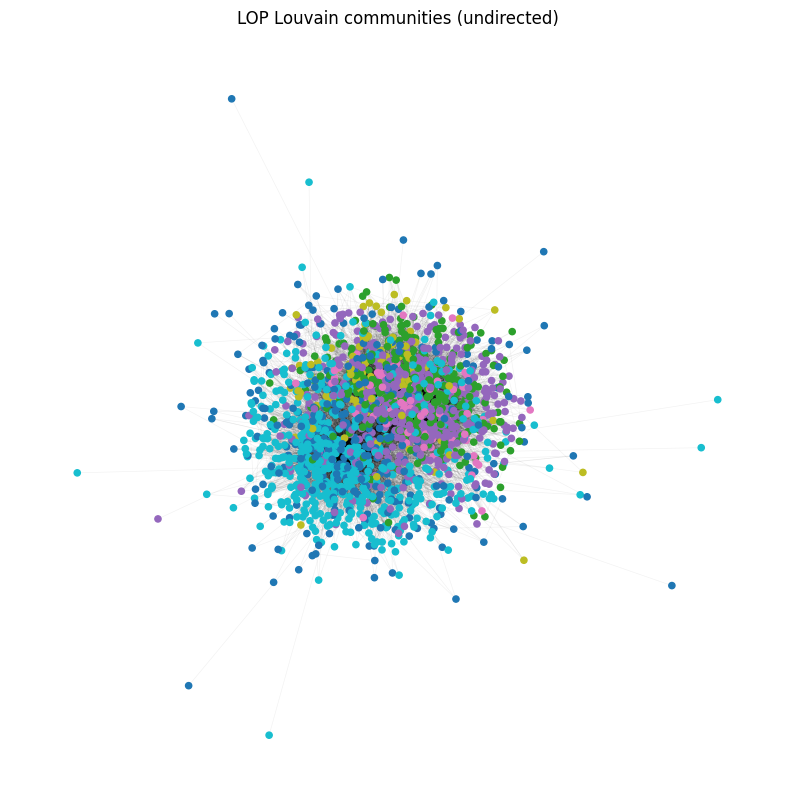

In [32]:
plt.figure(figsize=(10, 10))

nx.draw_networkx_edges(
    G_undirected,
    pos,
    alpha=0.05,
    width=0.5
)

nodes = list(G_undirected.nodes())
communities = np.array([node_to_louvain[n] for n in nodes])

nx.draw_networkx_nodes(
    G_undirected,
    pos,
    node_size=20,
    node_color=communities,
    cmap="tab10"
)

plt.title("LOP Louvain communities (undirected)")
plt.axis("off")
plt.show()
